In [51]:
import numpy as np
import pandas as pd
import random
from random import randint
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import xgboost as xgb
from util_game import *
from util_strategy import *

In [69]:
def plot_zero_one(arr, label=None):
    plt.plot( np.linspace(0, 1, len(arr)) , arr, label=label  )
def plot_zero_one_sorted(arr, label=None):
    arr=np.array(arr)
    plot_zero_one(np.sort(arr),label=label)

In [47]:
np.random.normal(0, 0.1, 2)

array([-0.02352247,  0.12215431])

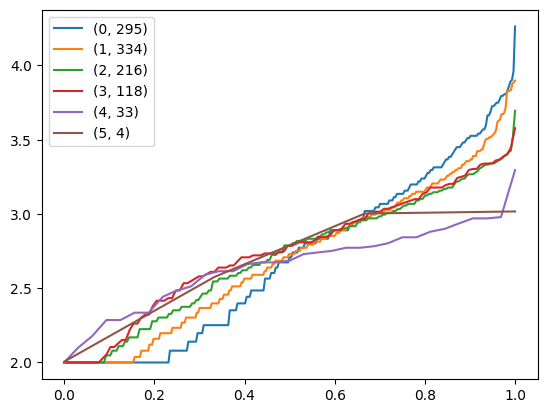

In [187]:
#for k in range(30):
game_value = get_game_value()
ylst={}
yylst=[]
for i in range(15):
    ylst[i]=[]
for j in range(1000):
    picked = sample_picked_once(game_value)
    now_d = picked[4]
    y = get_yield_by_picked(picked)
    yylst.append(y)
    y=y//(2**now_d)
    y/=(now_d+2)
    y = np.log(y+1)
    if y<2.0:
        y=2.0
    ylst[now_d].append(y)
#plot_zero_one_sorted(yylst, label=-1)
for i in range(10):
    if len(ylst[i])>=2:
        plot_zero_one_sorted(ylst[i], label=(i,len(ylst[i])))
plt.legend()
plt.show()

4 8


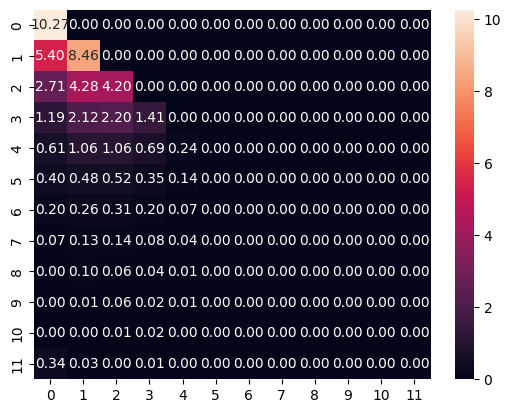

C:\Users\zhiha\AppData\Local\Temp\ipykernel_292\2183016532.py:25: RuntimeWarning: divide by zero encountered in log
  plot_series(np.log(np.sum(mapv,axis=0)))


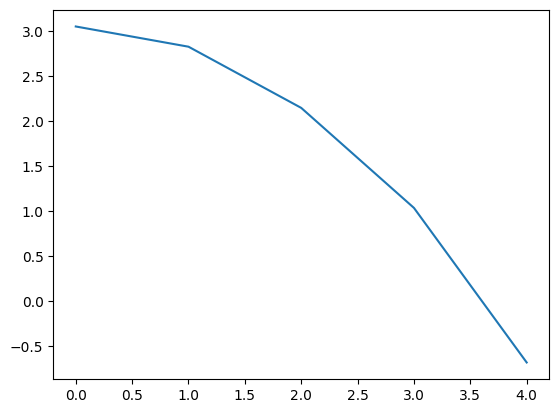

1 2


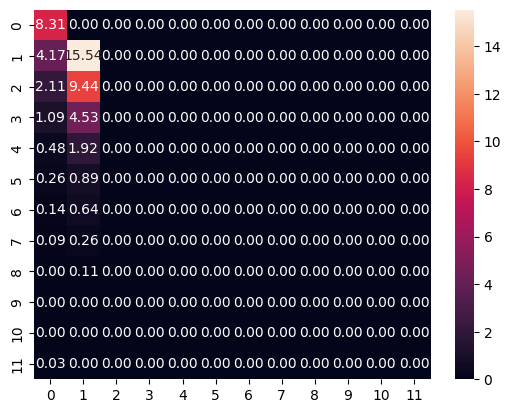

C:\Users\zhiha\AppData\Local\Temp\ipykernel_292\2183016532.py:25: RuntimeWarning: divide by zero encountered in log
  plot_series(np.log(np.sum(mapv,axis=0)))


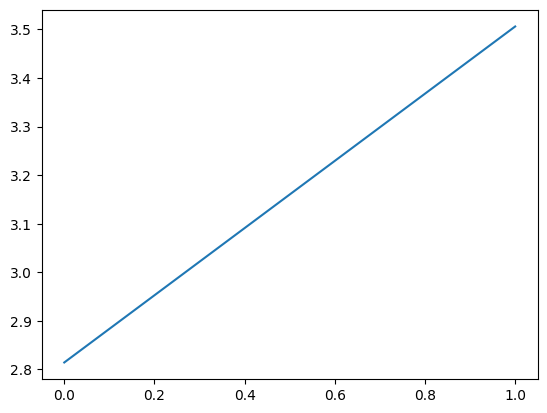

1 2


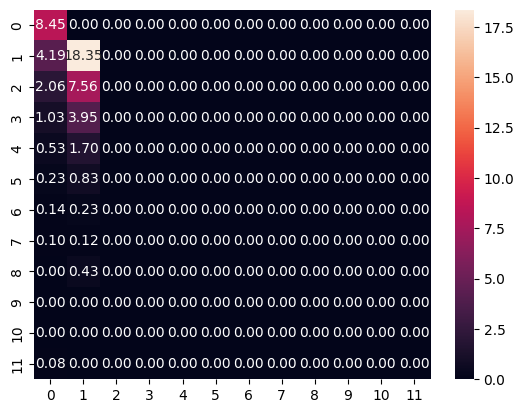

C:\Users\zhiha\AppData\Local\Temp\ipykernel_292\2183016532.py:25: RuntimeWarning: divide by zero encountered in log
  plot_series(np.log(np.sum(mapv,axis=0)))


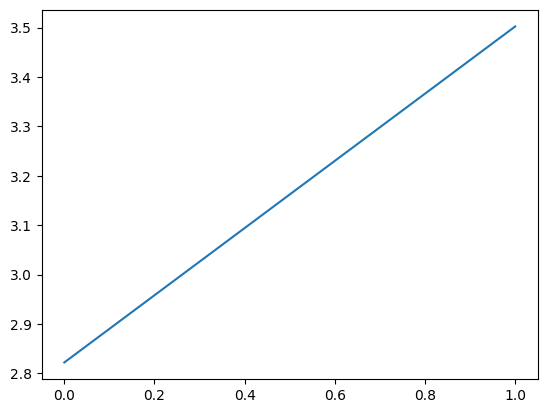

In [219]:
for k in range(3):
    d=0
    b=3
    while d*2!=b:
        game_value = get_game_value()
        d = game_value[4]
        b = game_value[3]
    print(d,b)
    mapv=np.zeros((12,12))
    for k in range(50000):
        picked = sample_picked_once(game_value)
        now_d = picked[4]
        y = get_yield_by_picked(picked)
        now_max_d = 0
        ty=y
        while ty%2==0 and now_max_d<=10:
            ty//=2
            now_max_d+=1
        mapv[now_max_d,now_d]+=1.0
    mapv/=np.sum(mapv)
    mapv*=50.0
    sns.heatmap(mapv, annot=True, fmt=".2f")
    #plt.plot(blst,dlst,'.')
    plt.show()
    plot_series(np.log(np.sum(mapv,axis=0)))

In [197]:
a = np.array([[1,2],[10,11]])
np.sum(a,axis=1)

array([ 3, 21])

In [61]:
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

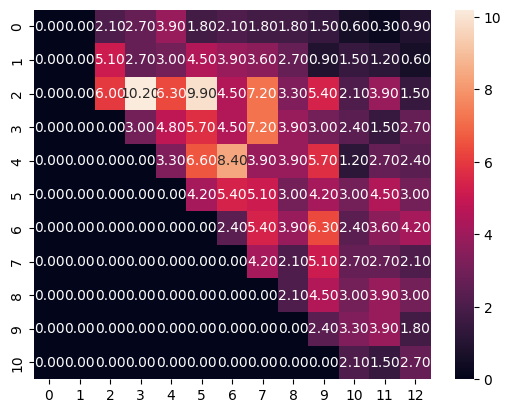

In [59]:
dlst=[]
blst=[]
mapv=np.zeros((11,13))
for k in range(1000):
    game_value = get_game_value()
    d = game_value[4]
    b = game_value[3]
    r = np.random.normal(0, 0.1, 2)
    dlst.append(d+r[0])
    blst.append(b+r[1])
    mapv[d,b]+=1.0
mapv/=np.sum(mapv)
mapv*=300.0
sns.heatmap(mapv, annot=True, fmt=".2f")
#plt.plot(blst,dlst,'.')
plt.show()

3 11
0.9999999999999999
0 5
1.0
6 7
0.9999999999999999
1 3
1.0
5 6
1.0


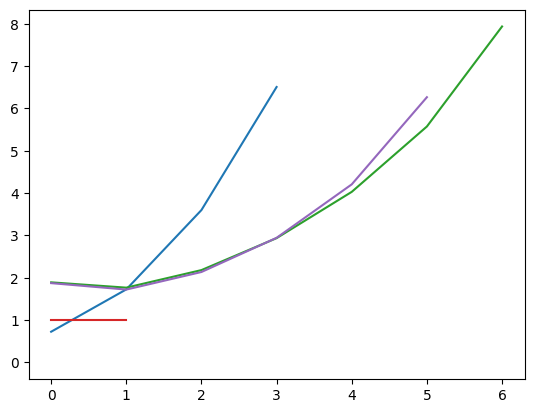

In [208]:
for k in range(5):
    game_value = get_game_value()
    d = game_value[4]
    b = game_value[3]
    print(d,b)
    res=0.0
    lst = []
    for i in range(d+1):
        now=2.0*binom(d,i)*binom(b,2)/binom(d+b,i+2)/(i+2)
        res+=now
        lst.append(now)
    print(res)
    arr=np.array(lst)
    arr=-np.log2(arr)
    plt.plot(arr)
plt.show()

-4.807232885535239 1.9489845425506742


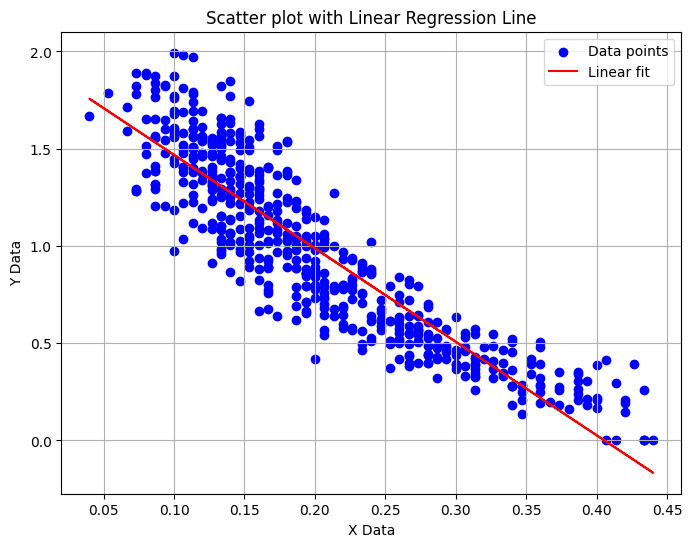

In [24]:
oddlst = []
dianumlst = []
for i in range(600):
    game_value = get_game_value()
    cnt = 0
    dianum = 0
    for j in range(150):
        picked, mining_time_first, mining_time = sample_picked_once_with_time(game_value)
        y = get_yield_by_picked(picked)
        if y%2:
            cnt+=1
        dianum += picked[4]
    oddlst.append(cnt/150)
    dianumlst.append(dianum/150)
oddlst2 = [oddlst[i] for i, x in enumerate(oddlst) if x <0.45]
dianumlst2 = [dianumlst[i] for i, x in enumerate(oddlst) if x <0.45]
scatter_with_linear_by_lists(oddlst2, dianumlst2)
#arr=np.array(oddlst)
#plot_series(np.sort(arr))

In [23]:
def scatter_with_linear_by_lists(x_data, y_data):

    # Perform linear regression
    slope, intercept = np.polyfit(x_data, y_data, 1)
    
    # Create scatter plot with linear regression line
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, color='blue', label='Data points')
    
    # Plot the linear regression line
    plt.plot(x_data, np.polyval([slope, intercept], x_data), color='red', label='Linear fit')
    print(slope, intercept)
    
    # Add labels and title
    plt.title('Scatter plot with Linear Regression Line')
    plt.xlabel('X Data')
    plt.ylabel('Y Data')
    
    # Show legend and grid
    plt.legend()
    plt.grid(True)
    
    # Display the plot
    plt.show()

In [14]:
x = [1,2,6,7]

In [20]:
list1 = [1, 2, 3, 4]
list2 = ['a', 'b', 'c', 'd']

# Using zip() to combine lists into a list of tuples
combined_list = list(zip(list1, list2))

print(combined_list)

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]
